In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]

src_dir = project_root / "src"

sys.path.append(str(src_dir))

print(src_dir)

/Users/isaacirwin/Desktop/gsp-finance/src


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from gsp_finance.graphs.laplacian import combinatorial_laplacian
from gsp_finance.gsp.filters import simple_low_pass_filter
from gsp_finance.gsp.fourier import dirichlet_energy, graph_fourier_transform


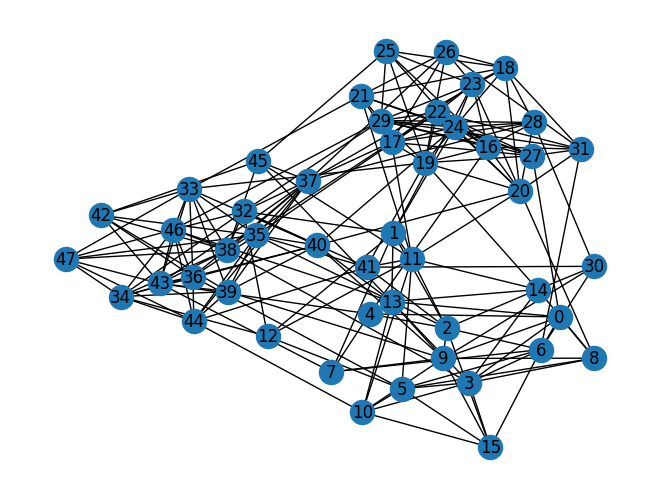

In [3]:
sizes = [16, 16, 16]
p_in = 0.5
p_out = 0.08
probs = [
    [p_in,  p_out, p_out],
    [p_out, p_in,  p_out],
    [p_out, p_out, p_in],
]
G = nx.stochastic_block_model(
    sizes=sizes,
    p=probs,
    seed=0

)
nx.draw(G, with_labels=True)
plt.show()

In [4]:
A = nx.adjacency_matrix(G).todense()
L = combinatorial_laplacian(A)
print("Laplacian:\n", L)

Laplacian:
 [[ 7  0  0 ...  0  0  0]
 [ 0  8 -1 ...  0  0  0]
 [ 0 -1  9 ...  0  0  0]
 ...
 [ 0  0  0 ...  6  0  0]
 [ 0  0  0 ...  0 10 -1]
 [ 0  0  0 ...  0 -1  7]]


In [5]:
eigenvalues, eigenvectors = np.linalg.eigh(L)

smooth_signal = np.ones(48, dtype=float)
rough_signal = np.array([1, -1] * 24, dtype=float)
middle_signal = np.array([1] * 16 + [-1] * 16 + [0] * 16, dtype=float)


smooth_hat = graph_fourier_transform(smooth_signal, eigenvectors)
rough_hat = graph_fourier_transform(rough_signal, eigenvectors)
middle_hat = graph_fourier_transform(middle_signal, eigenvectors)

print("Eigenvalues:", eigenvalues)

print("Smoothness smooth:", dirichlet_energy(smooth_signal, L))

print("Smoothness rough:", dirichlet_energy(rough_signal, L))

print("Smoothness middle:", dirichlet_energy(middle_signal, L))

print("Smooth Fourier coefficients:", smooth_hat)

print("Rough Fourier coefficients:", rough_hat)

print("Middle Fourier coefficients:", middle_hat)



Eigenvalues: [-6.62135431e-15  1.89345378e+00  2.24797214e+00  3.37132193e+00
  3.82232011e+00  4.05143432e+00  4.72860272e+00  4.84835007e+00
  5.37112404e+00  5.78126688e+00  5.86084357e+00  6.08622217e+00
  6.24225296e+00  6.45549349e+00  6.67523243e+00  6.84585089e+00
  7.10369362e+00  7.23562612e+00  7.66294688e+00  7.68469405e+00
  7.91863845e+00  8.07517823e+00  8.40621487e+00  8.73326524e+00
  9.03747123e+00  9.36136668e+00  9.46263094e+00  9.54666825e+00
  9.80605050e+00  9.95741076e+00  1.01497690e+01  1.03759253e+01
  1.05259371e+01  1.10607515e+01  1.12880082e+01  1.13232365e+01
  1.15344038e+01  1.16518011e+01  1.21046956e+01  1.23637011e+01
  1.28039225e+01  1.30232987e+01  1.32801395e+01  1.34857041e+01
  1.36208895e+01  1.44161001e+01  1.51698772e+01  1.55482418e+01]
Smoothness smooth: 0.0
Smoothness rough: 444.0
Smoothness middle: 84.0
Smooth Fourier coefficients: [ 6.92820323e+00  3.77475828e-15 -2.30371278e-15 -3.38618023e-15
  1.81105131e-15 -1.22124533e-15  6.38378

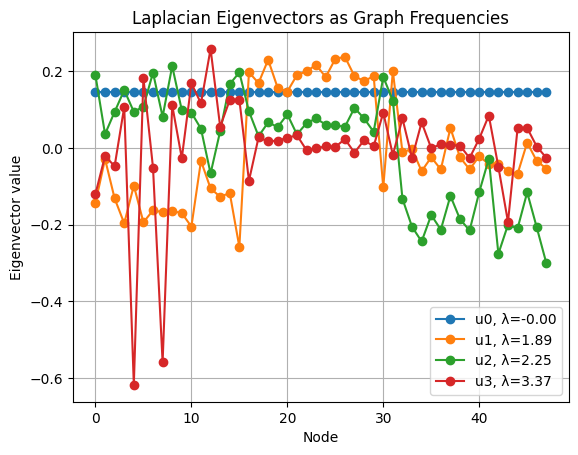

In [6]:
plt.figure()
for i in range(4):
    plt.plot(eigenvectors[:, i], marker="o", label=f"u{i}, λ={eigenvalues[i]:.2f}")
plt.title("Laplacian Eigenvectors as Graph Frequencies")
plt.xlabel("Node")
plt.ylabel("Eigenvector value")
plt.legend()
plt.grid(True)
plt.show()

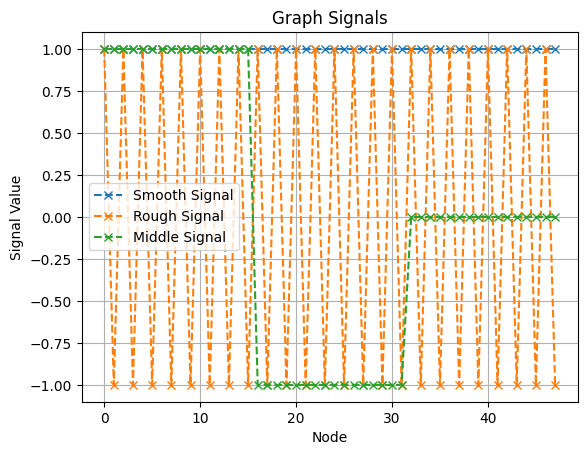

In [7]:
plt.plot(smooth_signal, marker="x", label="Smooth Signal", linestyle="--")
plt.plot(rough_signal, marker="x", label="Rough Signal", linestyle="--")
plt.plot(middle_signal, marker="x", label="Middle Signal", linestyle="--")
plt.title("Graph Signals")
plt.xlabel("Node")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)

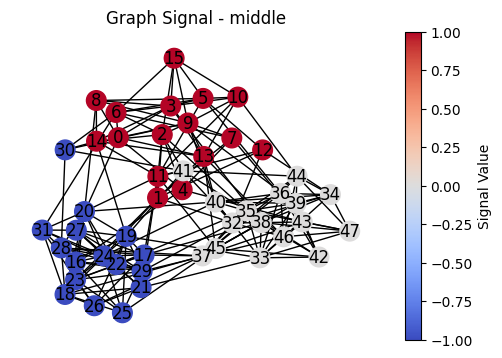

In [10]:
signals = [smooth_signal, rough_signal, middle_signal]
signal = signals[2]  # or signals[0] or signals[2]
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=200,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title(f"Graph Signal - {'smooth' if signal is smooth_signal else 'rough' if signal is rough_signal else 'middle'}")
plt.axis("off")
plt.show()

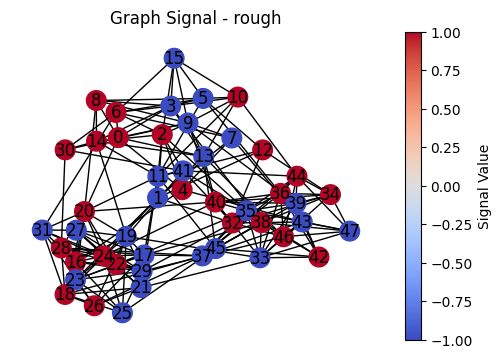

In [11]:
signal = rough_signal  # or smooth
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=200,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title("Graph Signal - rough")
plt.axis("off")
plt.show()

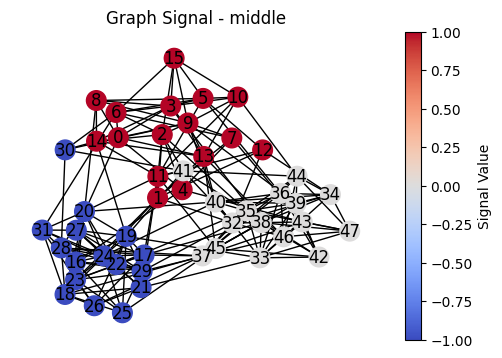

In [52]:
signal = middle_signal
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=200,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title("Graph Signal - middle")
plt.axis("off")
plt.show()

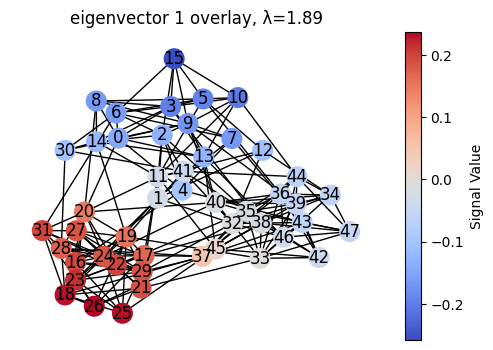

[-0.14363622 -0.02906785 -0.13191533 -0.19683181 -0.09844266 -0.19387305
 -0.16294602 -0.16749637 -0.16451693 -0.17016643 -0.20528019 -0.03380268
 -0.10591271 -0.12742313 -0.1177695  -0.25837109  0.19694351  0.16868064
  0.22948804  0.15589882  0.14668064  0.18939001  0.19956087  0.2161662
  0.18428329  0.2317185   0.23718284  0.18684196  0.17388441  0.18689079
 -0.10280435  0.19989084 -0.01140342 -0.00304602 -0.06087573 -0.02452726
 -0.05623329  0.05167061 -0.02497824 -0.05597608 -0.02204236 -0.04236891
 -0.0412926  -0.05971225 -0.06780457  0.01361058 -0.03435456 -0.05391092]


In [12]:
k = 1
signal = eigenvectors[:, k]
signal = np.round(signal, 10) 
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=200,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title(f"eigenvector {k} overlay, λ={eigenvalues[k]:.2f}")
plt.axis("off")
plt.show()
print(eigenvectors[:, k])

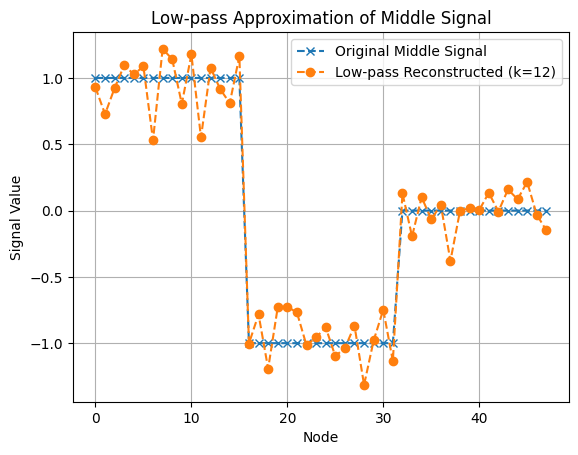

In [20]:
k = 12
middle_low_reconstructed = simple_low_pass_filter(middle_signal, eigenvectors, k)

plt.plot(middle_signal, marker="x", label="Original Middle Signal", linestyle="--")
plt.plot(middle_low_reconstructed, marker="o", label=f"Low-pass Reconstructed (k={k})", linestyle="--")
plt.title("Low-pass Approximation of Middle Signal")
plt.xlabel("Node")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.show()

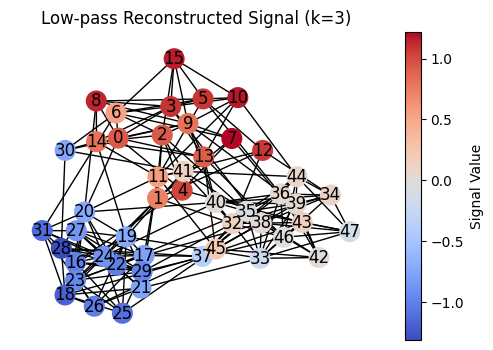

In [55]:
signal = middle_low_reconstructed
pos = nx.spring_layout(G, seed=0)
plt.figure(figsize=(6, 4))
nx.draw_networkx_edges(G, pos)
nodes = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=signal,
    cmap="coolwarm",
    node_size=200,
)
nx.draw_networkx_labels(G, pos)
plt.colorbar(nodes, label="Signal Value")
plt.title("Low-pass Reconstructed Signal (k=3)")
plt.axis("off")
plt.show()

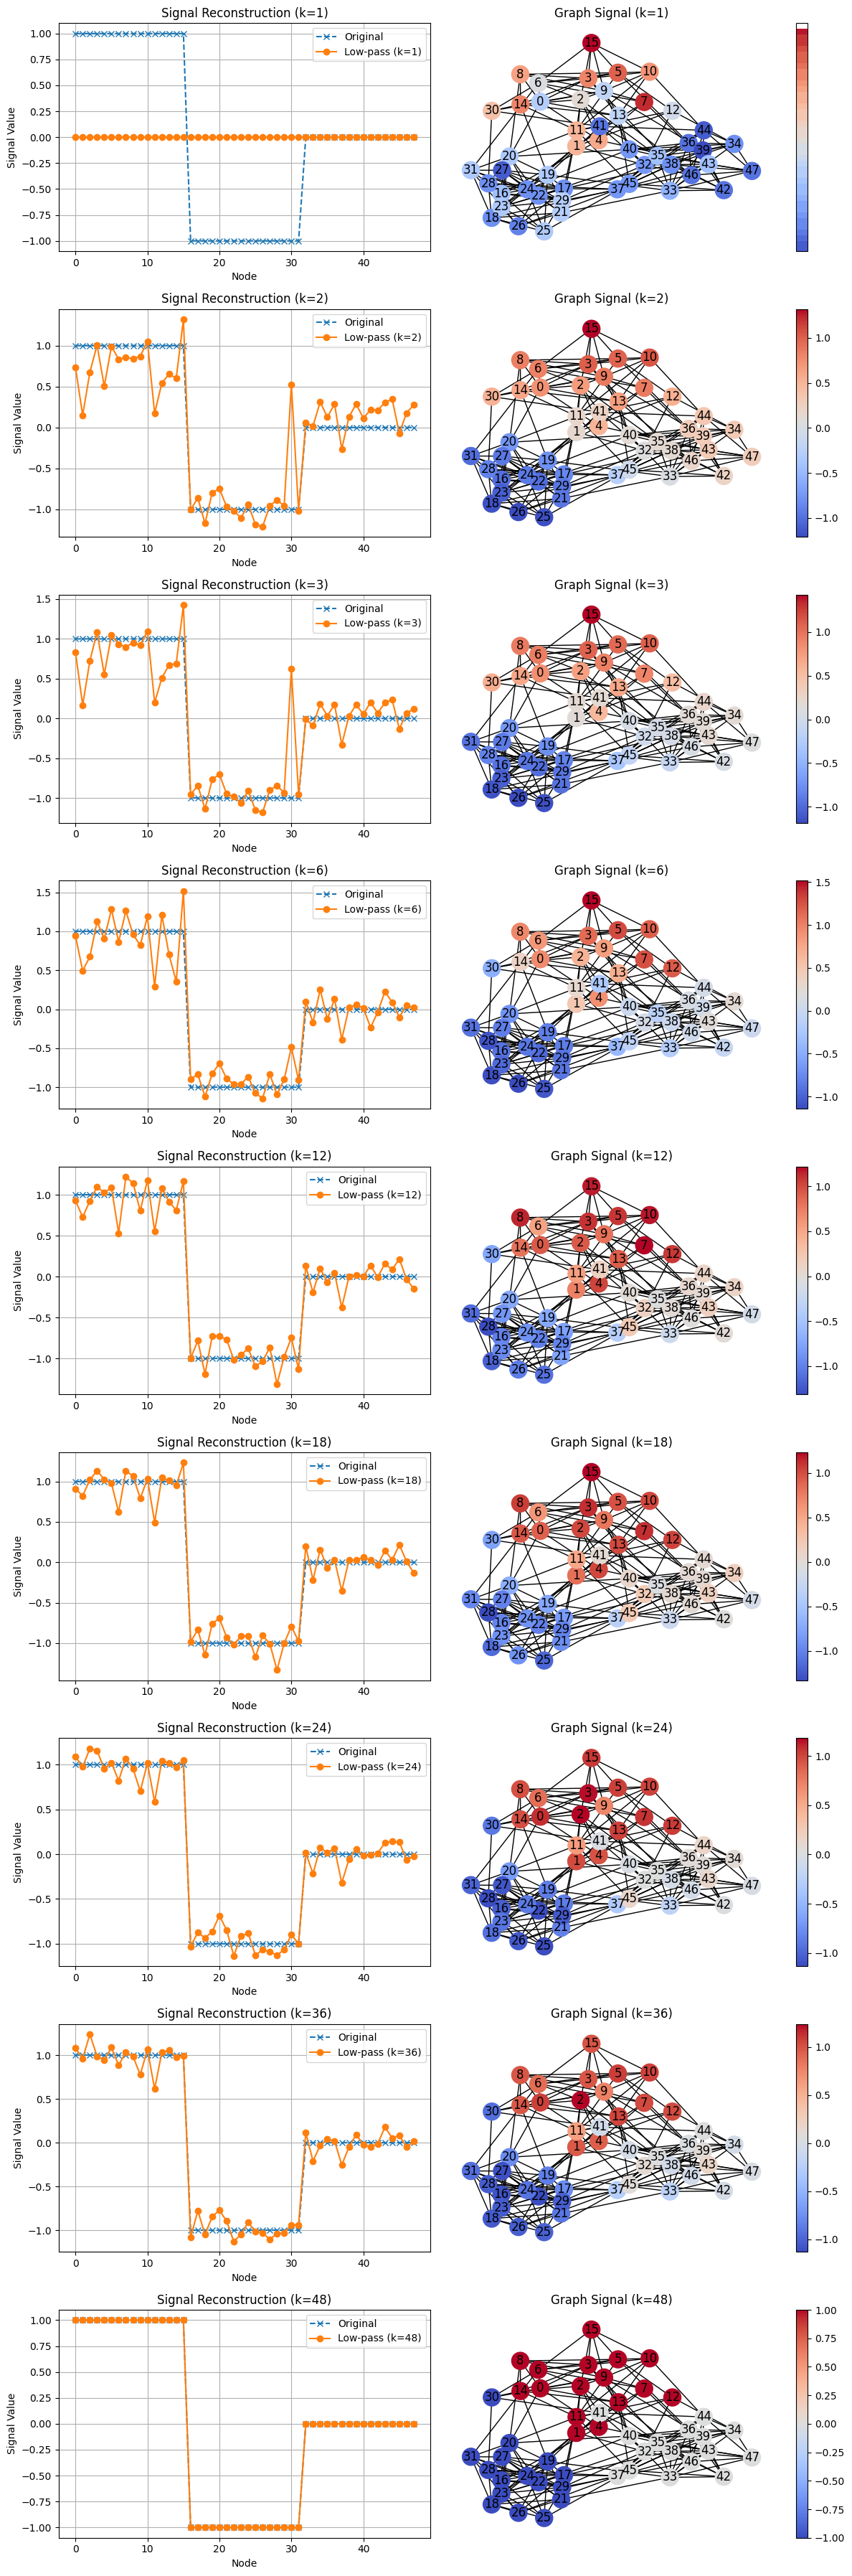

In [59]:
ks = [1, 2, 3, 6, 12, 18, 24, 36, 48]

fig, axes = plt.subplots(
    nrows=len(ks),
    ncols=2,
    figsize=(12, 4 * len(ks))
)

pos = nx.spring_layout(G, seed=0)

for row, k in enumerate(ks):

    reconstructed = simple_low_pass_filter(
        middle_signal,
        eigenvectors,
        k
    )

    ax_signal = axes[row, 0]

    ax_signal.plot(
        middle_signal,
        marker="x",
        linestyle="--",
        label="Original"
    )

    ax_signal.plot(
        reconstructed,
        marker="o",
        linestyle="-",
        label=f"Low-pass (k={k})"
    )

    ax_signal.set_title(f"Signal Reconstruction (k={k})")
    ax_signal.set_xlabel("Node")
    ax_signal.set_ylabel("Signal Value")
    ax_signal.grid(True)
    ax_signal.legend()

    ax_graph = axes[row, 1]

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax_graph
    )

    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_color=reconstructed,
        cmap="coolwarm",
        node_size=300,
        ax=ax_graph
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax_graph
    )

    ax_graph.set_title(f"Graph Signal (k={k})")
    ax_graph.axis("off")

    plt.colorbar(
        nodes,
        ax=ax_graph,
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()
plt.show()